[199.59766633 200.52214247 199.88890712 202.09069674 201.36095916
 199.1554884  200.86861342 200.815155   199.69645289 198.98194827]
[201.08046283 199.22526873 199.84551246 199.90724936 200.10258494
 201.81318105 200.33565575 198.72359594 201.42542903 201.25017342]
[1.4827965  1.29687373 0.04339466 2.18344738 1.25837422 2.65769264
 0.53295766 2.09155906 1.72897614 2.26822515]


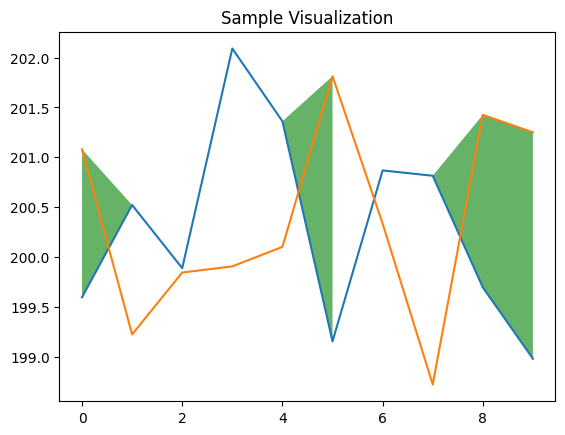

In [1]:
import numpy as np
from matplotlib import pyplot as plt

sample1 = 200 + np.random.randn(10)
print(sample1)

sample2 = 200 + np.random.randn(10)
print(sample2)

print(abs(sample1 - sample2))
x = [x for x in range(len(sample2))]
plt.plot(x, sample1, '-')
plt.plot(x, sample2, '-')
plt.fill_between(x, sample1, np.maximum(sample1, sample2), where=(abs(sample1-sample2) > 1), facecolor='g', alpha=0.6)

plt.title('Sample Visualization')
plt.show()

In [2]:
import tensorflow as tf

inputs = tf.keras.Input(shape=(3,))
layer1 = tf.keras.layers.Dense(4, activation=tf.nn.relu)(inputs)
outputs = tf.keras.layers.Dense(5, activation=tf.nn.softmax)(layer1)
FuncAPIModel = tf.keras.Model(inputs=inputs, outputs=outputs)

In [3]:
class SubcModel(tf.keras.Model):
    def __init__(self):
        super(SubcModel, self).__init__()
        self.dense1 = tf.keras.layers.Dense(4, activation=tf.nn.relu)
        self.dense2 = tf.keras.layers.Dense(5, activation=tf.nn.softmax)
    
    def call(self, inputs):
        x = self.dense1(inputs)
        return self.dense2(x)

model = SubcModel()

In [4]:
class SubcModel2(tf.keras.Model):
    def __init__(self):
        super(SubcModel2, self).__init__()
        self.dense1 = tf.keras.layers.Dense(4, activation=tf.nn.relu)
        self.dense2 = tf.keras.layers.Dense(5, activation=tf.nn.softmax)
        self.dropout = tf.keras.layers.Dropout(0.5)
    
    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        if training:
            x = self.dropout(x, training=training)
        return self.dense2(x)

model = SubcModel2()

In [5]:
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(16,)))
model.add(tf.keras.layers.Dense(8))

In [6]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(8))
model.add(tf.keras.layers.Dense(4))
model.build((None, 16))

In [8]:
model.summary(line_length=None, positions=None, print_fn=None)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 172 (688.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf
import tensorflow.keras.layers as keras_layers

layer1 = keras_layers.Dense(1, kernel_initializer=tf.constant_initializer(5,))
layer1_out = layer1(tf.convert_to_tensor([[1., 2., 3.]]))
layer1.get_weights()

[array([[5.],
        [5.],
        [5.]], dtype=float32),
 array([0.], dtype=float32)]

In [11]:

layer2 = keras_layers.Dense(1, kernel_initializer=tf.constant_initializer(2.))
layer2_out = layer2(tf.convert_to_tensor([[10., 20., 30.]]))
layer2.get_weights()


[array([[2.],
        [2.],
        [2.]], dtype=float32),
 array([0.], dtype=float32)]

In [12]:

layer2.set_weights(layer1.get_weights())
layer2.get_weights()

[array([[5.],
        [5.],
        [5.]], dtype=float32),
 array([0.], dtype=float32)]

In [14]:
import tensorflow as tf
from tensorflow.keras import layers

layer = layers.Dense(32, activation='relu')
inputs = tf.random.uniform(shape=(10, 20))
out = layer(inputs)

In [15]:
class exDense(layers.Layer):
    def __init__(self, units=32):
        super(exDense, self).__init__()
        self.units = units
    def build(self, input_shape):
        w_init = tf.random_normal_initializer()
        self.w = tf.Variable(
            initial_value=w_init(shape=(input_shape[-1], self.units), dtype='float32'), trainable=True, name='weight'
        )
        b_init = tf.ones_initializer()
        self.b = tf.Variable(
            initial_value=b_init(shape=(self.units,), dtype='float32'),
            trainable=True, name='bias'
        )
    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

In [18]:
exDense_layer = exDense(4)

before_w = exDense_layer.weights
print('all weights(before)', before_w)

out = exDense_layer(tf.ones((3, 3)))
print('\noutputs:', out)

after_w = exDense_layer.weights
print('\nall weights(after)', after_w)

all weights(before) []

outputs: tf.Tensor(
[[0.99576354 1.0002829  1.1268355  1.0205154 ]
 [0.99576354 1.0002829  1.1268355  1.0205154 ]
 [0.99576354 1.0002829  1.1268355  1.0205154 ]], shape=(3, 4), dtype=float32)

all weights(after) []


In [19]:
t_w = exDense_layer.trainable_weights
print('\ntrainable weights', t_w)

nt_w = exDense_layer.non_trainable_weights
print('\nnon_trainable_weights', nt_w)

t_v = exDense_layer.trainable_variables
print('\ntrainable_variables', t_v)

nt_v = exDense_layer.non_trainable_variables
print('\nnon_trainable_variables', nt_v)


trainable weights []

non_trainable_weights []

trainable_variables []

non_trainable_variables []


In [20]:
class exDense(layers.Layer):
    def __init__(self, units=32):
        super(exDense, self).__init__()
        self.units = units
    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='random_normal',
                                 trainable=True, name='weight')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='random_normal',
                                 trainable=True, name='bias')
    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

In [21]:
exDense_layer = exDense(4)

before_w = exDense_layer.weights
print('all weights(before)', before_w)

out = exDense_layer(tf.ones((3, 3)))
print('\noutputs:', out)

after_w = exDense_layer.weights
print('\nall weights(after)', after_w)

all weights(before) []

outputs: tf.Tensor(
[[ 0.18843481  0.17066225 -0.10982445 -0.11657169]
 [ 0.18843481  0.17066225 -0.10982445 -0.11657169]
 [ 0.18843481  0.17066225 -0.10982445 -0.11657169]], shape=(3, 4), dtype=float32)

all weights(after) [<Variable path=ex_dense_3/weight, shape=(3, 4), dtype=float32, value=[[ 0.02881054  0.02170385 -0.07071821  0.01055389]
 [ 0.08405412  0.05801085 -0.06480777  0.02100923]
 [ 0.03768284  0.04465793  0.02228448 -0.06901035]]>, <Variable path=ex_dense_3/bias, shape=(4,), dtype=float32, value=[ 0.03788731  0.04628962  0.00341705 -0.07912447]>]


In [22]:
t_w = exDense_layer.trainable_weights
print('\ntrainable weights', t_w)

nt_w = exDense_layer.non_trainable_weights
print('\nnon_trainable_weights', nt_w)

t_v = exDense_layer.trainable_variables
print('\ntrainable_variables', t_v)

nt_v = exDense_layer.non_trainable_variables
print('\nnon_trainable_variables', nt_v)


trainable weights [<Variable path=ex_dense_3/weight, shape=(3, 4), dtype=float32, value=[[ 0.02881054  0.02170385 -0.07071821  0.01055389]
 [ 0.08405412  0.05801085 -0.06480777  0.02100923]
 [ 0.03768284  0.04465793  0.02228448 -0.06901035]]>, <Variable path=ex_dense_3/bias, shape=(4,), dtype=float32, value=[ 0.03788731  0.04628962  0.00341705 -0.07912447]>]

non_trainable_weights []

trainable_variables [<Variable path=ex_dense_3/weight, shape=(3, 4), dtype=float32, value=[[ 0.02881054  0.02170385 -0.07071821  0.01055389]
 [ 0.08405412  0.05801085 -0.06480777  0.02100923]
 [ 0.03768284  0.04465793  0.02228448 -0.06901035]]>, <Variable path=ex_dense_3/bias, shape=(4,), dtype=float32, value=[ 0.03788731  0.04628962  0.00341705 -0.07912447]>]

non_trainable_variables []


In [23]:
from tensorflow.keras import layers
from tensorflow.keras import activations

model.add(layers.Dense(64))
model.add(layers.Activation(activations.relu))

In [25]:
norm = tf.random.normal([1, 5], mean=-1, stddev=10, dtype='half')
print('input: ', norm)

tf.keras.activations.relu(norm).numpy()

input:  tf.Tensor([[  4.348  -1.588   0.587 -11.24  -20.08 ]], shape=(1, 5), dtype=float16)


array([[4.348, 0.   , 0.587, 0.   , 0.   ]], dtype=float16)

In [27]:
al = tf.keras.activations.relu(norm, negative_slope=0.5)
max_v = tf.keras.activations.relu(norm, max_value=1)
thres = tf.keras.activations.relu(norm, threshold=norm[0, 0])
print('alpha : ', al)
print('\nmax_value : ', max_v)
print('\nthreshold : ', thres)

alpha :  tf.Tensor([[  4.348  -0.794   0.587  -5.62  -10.04 ]], shape=(1, 5), dtype=float16)

max_value :  tf.Tensor([[1.    0.    0.587 0.    0.   ]], shape=(1, 5), dtype=float16)

threshold :  tf.Tensor([[ 0. -0.  0. -0. -0.]], shape=(1, 5), dtype=float16)


sigmoid :  tf.Tensor(
[4.5397861e-05 6.6928524e-03 1.1920294e-01 5.0000000e-01 8.8079709e-01
 9.9330717e-01 9.9995458e-01], shape=(7,), dtype=float32)


Text(0.5, 1.0, 'Sigmoid Visualization')

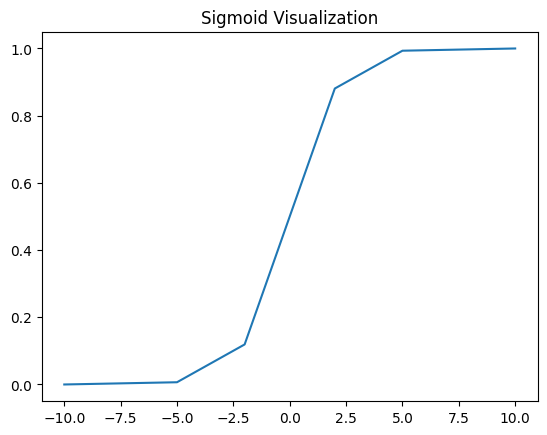

In [28]:
from matplotlib import pyplot as plt

in1 = tf.constant([-10, -5.0, -2.0, 0.0, 2.0, 5.0, 10], dtype=tf.float32)
out1 = tf.keras.activations.sigmoid(in1)
print('sigmoid : ', out1)

plt.plot(in1, out1)
plt.title('Sigmoid Visualization')

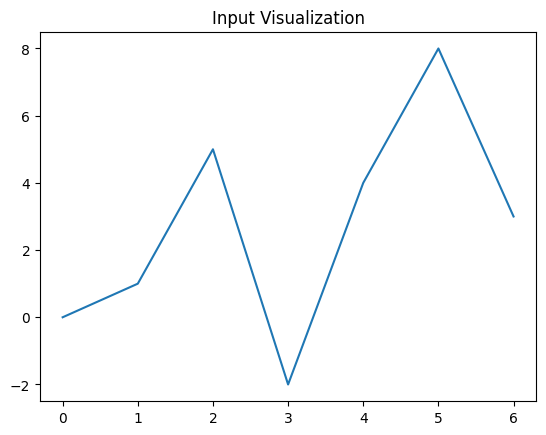

softmax :  [[3.1172964e-04 8.4736891e-04 4.6264775e-02 4.2188018e-05 1.7019859e-02
  9.2925286e-01 6.2612561e-03]]

sum of softmax :  1.0


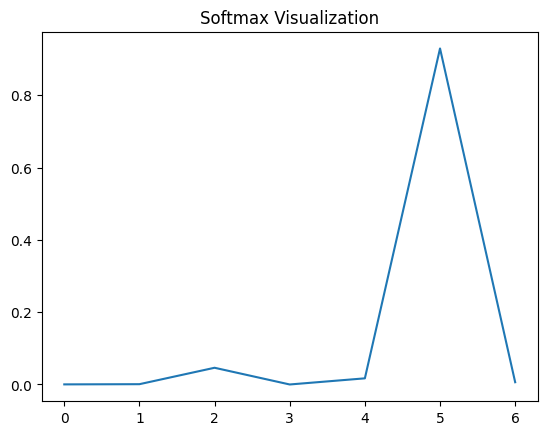

In [29]:
in2 = tf.constant([[0.0, 1.0, 5.0, -2.0, 4.0, 8.0, 3.0]], dtype=tf.float32)
plt.plot(in2[0, :])
plt.title('Input Visualization')
plt.show()

out2 = tf.keras.activations.softmax(in2, axis=1).numpy()
print('softmax : ', out2)
print('\nsum of softmax : ', out2.sum())

x = [x for x in range(7)]
plt.plot(x, out2[0, x], '-')

plt.title('Softmax Visualization')
plt.show()

In [30]:
from tensorflow.keras import layers
from tensorflow.keras import initializers

layer = layers.Dense(
    units=64,
    kernel_initializer=initializers.RandomNormal(stddev=0.01),
    bias_initializer=initializers.Zeros()
)

layer = layers.Dense(
    units=64,
    kernel_initializer='random_normal',
    bias_initializer='zeros'
)

In [32]:
import tensorflow as tf
from tensorflow.keras import initializers

norm_init1 = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
norm_init2 = tf.keras.initializers.RandomNormal(mean=0., stddev=1., seed=100)

for i in range(3):
    values1 = norm_init1(shape=(2, 2)).numpy()
    values2 = norm_init2(shape=(2, 2)).numpy()
    print(i, 'initializer1 : ', values1)
    print(i, 'initializer2 : ', values2)

0 initializer1 :  [[-0.5068288   0.7666656 ]
 [ 0.28366995 -2.3395894 ]]
0 initializer2 :  [[ 1.7098777  -0.12379249]
 [-1.8377445   0.46580476]]
1 initializer1 :  [[-0.5068288   0.7666656 ]
 [ 0.28366995 -2.3395894 ]]
1 initializer2 :  [[ 1.7098777  -0.12379249]
 [-1.8377445   0.46580476]]
2 initializer1 :  [[-0.5068288   0.7666656 ]
 [ 0.28366995 -2.3395894 ]]
2 initializer2 :  [[ 1.7098777  -0.12379249]
 [-1.8377445   0.46580476]]


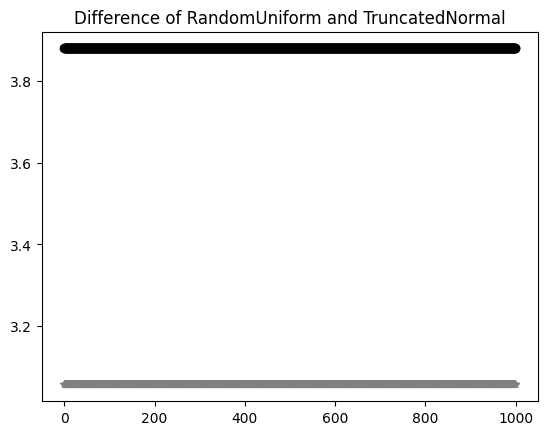

In [38]:
norm_init3 = tf.keras.initializers.RandomNormal(mean=0., stddev=5.)
tun_norm_init1 = tf.keras.initializers.TruncatedNormal(mean=0., stddev=5.)

for i in range(1000):
    value3 = norm_init3(shape=(1, 1)).numpy()
    value4 = tun_norm_init1(shape=(1, 1)).numpy()
    plt.plot(i, value3[0,0], 'o', color='black')
    plt.plot(i, value4[0,0], '*', color='gray')

plt.title('Difference of RandomUniform and TruncatedNormal')
plt.show()

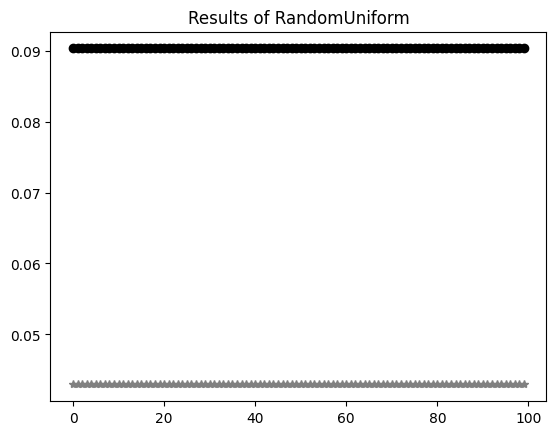

In [39]:
unif_init1 = tf.keras.initializers.RandomUniform(minval=0, maxval=1)
unif_init2 = tf.keras.initializers.RandomUniform(minval=-1, maxval=2)

for i in range(100):
    value3 = unif_init1(shape=(1, 1)).numpy()
    value4 = unif_init2(shape=(1, 1)).numpy()
    plt.plot(i, value3[0,0], 'o', color='black')
    plt.plot(i, value4[0,0], '*', color='gray')

plt.title('Results of RandomUniform')
plt.show()

In [40]:
init_ones = tf.keras.initializers.Ones()
init_zeros = tf.keras.initializers.Zeros()
init_constant = tf.keras.initializers.Constant(value=3)

print('one init : ', init_ones(shape=(1, 5)).numpy())
print('\nzeros init : ', init_zeros(shape=(1, 5)).numpy())
print('\nconstant init : ', init_constant(shape=(1, 5)).numpy())

one init :  [[1. 1. 1. 1. 1.]]

zeros init :  [[0. 0. 0. 0. 0.]]

constant init :  [[3. 3. 3. 3. 3.]]


In [41]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras import layers
from tensorflow.keras import Model

x = Input(shape=(32,))
y = layers.Dense(16, activation='softmax')(x)
model = Model(x, y)

norm = tf.random.normal([1, 32], mean=-1, stddev=10, dtype='half')
model(norm)

<tf.Tensor: shape=(1, 16), dtype=float32, numpy=
array([[1.9035445e-22, 1.3994247e-13, 1.3188674e-05, 8.5019385e-18,
        3.1592090e-13, 5.4868856e-11, 5.5167131e-02, 2.3497390e-03,
        2.6567748e-10, 5.2789492e-08, 4.3873752e-16, 8.1067670e-16,
        9.4246989e-01, 2.8212708e-13, 8.3267839e-18, 2.0649998e-16]],
      dtype=float32)>

In [42]:
input_shape = (3, 2, 1)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv1D(
    filters=1, kernel_size=2, activation=None, kernel_initializer='ones',
    input_shape=input_shape[1:]
)(x)

print('input ', x)
print('\nconv1D : ', y)

c:\Users\Jo\AppData\Local\Programs\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


input  tf.Tensor(
[[[-1.8568463 ]
  [-0.97645676]]

 [[-0.5565989 ]
  [ 0.62624943]]

 [[-0.6819063 ]
  [ 3.4440432 ]]], shape=(3, 2, 1), dtype=float32)

conv1D :  tf.Tensor(
[[[-2.833303  ]]

 [[ 0.06965053]]

 [[ 2.762137  ]]], shape=(3, 1, 1), dtype=float32)


In [43]:
input_shape = (3, 3, 1)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv1D(
    filters=2, kernel_size=2, activation=None, kernel_initializer='ones',
    input_shape=input_shape[1:]
)(x)

print('input ', x)
print('\nconv1D : ', y)

input  tf.Tensor(
[[[-0.07935166]
  [-0.00775294]
  [-0.22866268]]

 [[-1.066166  ]
  [ 0.9960841 ]
  [ 0.51117665]]

 [[ 0.5665329 ]
  [-2.3198211 ]
  [ 1.4553633 ]]], shape=(3, 3, 1), dtype=float32)

conv1D :  tf.Tensor(
[[[-0.0871046  -0.0871046 ]
  [-0.23641562 -0.23641562]]

 [[-0.07008195 -0.07008195]
  [ 1.5072608   1.5072608 ]]

 [[-1.7532883  -1.7532883 ]
  [-0.86445785 -0.86445785]]], shape=(3, 2, 2), dtype=float32)


c:\Users\Jo\AppData\Local\Programs\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
import tensorflow as tf

x = tf.constant([1., 3., 5., 7., 9., 2., 4., 6., 8., 10.])
x1 = tf.reshape(x, [1, 5, 2])
maxpool1d = tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding='valid')(x1)

print('input : ', x1)
print('\nmax pooling 1d : ', maxpool1d)

input :  tf.Tensor(
[[[ 1.  3.]
  [ 5.  7.]
  [ 9.  2.]
  [ 4.  6.]
  [ 8. 10.]]], shape=(1, 5, 2), dtype=float32)

max pooling 1d :  tf.Tensor(
[[[ 5.  7.]
  [ 9.  7.]
  [ 9.  6.]
  [ 8. 10.]]], shape=(1, 4, 2), dtype=float32)


In [45]:
x2 = tf.reshape(x, [1, 2, 5])
averagepool1d = tf.keras.layers.AveragePooling1D(pool_size=2, strides=1, padding='same')(x2)
print('input : ', x2)
print('\nAverage pooling 1d : ', averagepool1d)

input :  tf.Tensor(
[[[ 1.  3.  5.  7.  9.]
  [ 2.  4.  6.  8. 10.]]], shape=(1, 2, 5), dtype=float32)

Average pooling 1d :  tf.Tensor(
[[[ 1.5  3.5  5.5  7.5  9.5]
  [ 2.   4.   6.   8.  10. ]]], shape=(1, 2, 5), dtype=float32)


In [46]:
globalmaxpool1d = tf.keras.layers.GlobalMaxPooling1D()(x2)
globalaveragepool1d = tf.keras.layers.GlobalAveragePooling1D()(x2)

print('Global max pooling 1d : ', globalmaxpool1d)
print('\nGlobal average pooling 1d : ', globalaveragepool1d)

Global max pooling 1d :  tf.Tensor([[ 2.  4.  6.  8. 10.]], shape=(1, 5), dtype=float32)

Global average pooling 1d :  tf.Tensor([[1.5 3.5 5.5 7.5 9.5]], shape=(1, 5), dtype=float32)
